In [1]:
from statistics import correlation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
from sklearn.preprocessing import LabelEncoder



In [2]:
car_dataset=pd.read_csv("car_data.csv")

In [3]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
car_dataset.shape

(301, 9)

In [5]:
car_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


In [6]:
car_dataset.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [7]:
print(car_dataset["Fuel_Type"].value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64


In [8]:
print(car_dataset["Seller_Type"].value_counts())

Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64


In [9]:
print(car_dataset["Transmission"].value_counts())

Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


In [10]:
print(car_dataset["Owner"].value_counts())

Owner
0    290
1     10
3      1
Name: count, dtype: int64


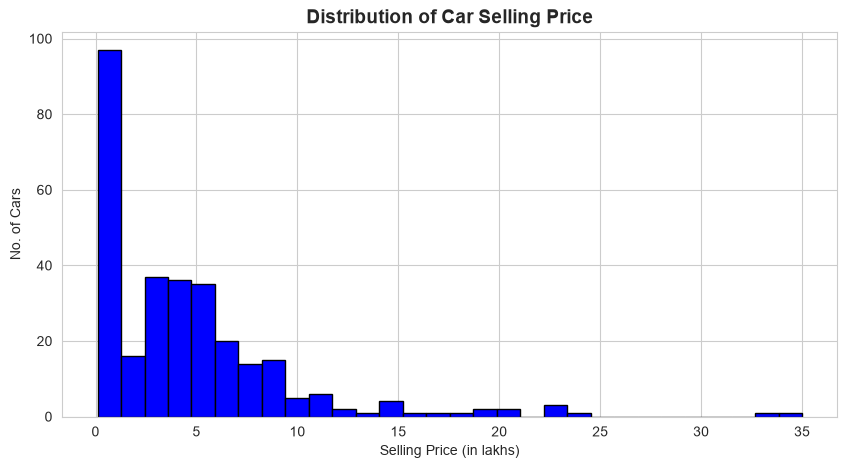

In [11]:
plt.figure(figsize=(10,5))
plt.hist(car_dataset["Selling_Price"],bins=30,color="Blue",edgecolor="black")
plt.title("Distribution of Car Selling Price",fontsize=14,fontweight="bold")
plt.xlabel("Selling Price (in lakhs)")
plt.ylabel("No. of Cars")
plt.show()

Text(0.5, 1.0, 'Feature Correlation Heatmap')

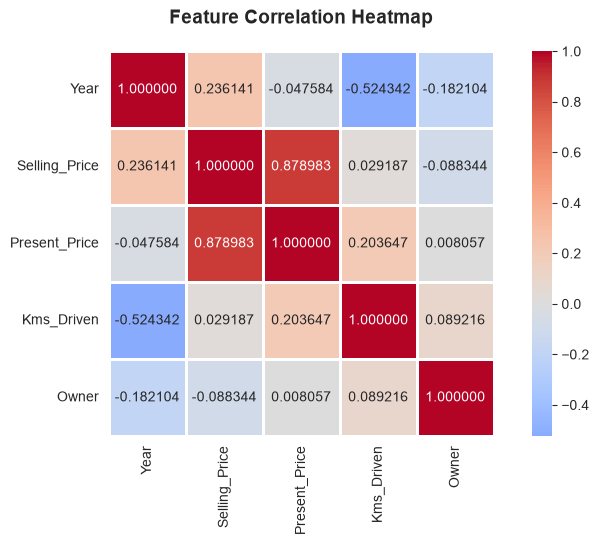

In [12]:
plt.figure(figsize=(10,5))
numeric_data=car_dataset.select_dtypes(include=[np.number])
correlation=numeric_data.corr()
sns.heatmap(correlation,annot=True,cmap="coolwarm",center=0,square=True,linewidths=1,fmt="2f")
plt.title("Feature Correlation Heatmap",fontsize=14,fontweight="bold",pad=20)

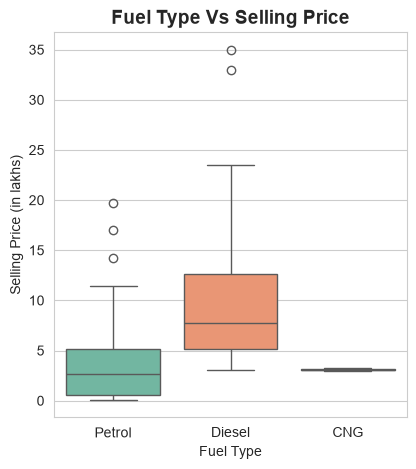

In [13]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.boxplot(x="Fuel_Type",y="Selling_Price",data=car_dataset,palette="Set2")
plt.title("Fuel Type Vs Selling Price",fontsize=14,fontweight="bold")
plt.ylabel("Selling Price (in lakhs)")
plt.xlabel("Fuel Type")
plt.show()

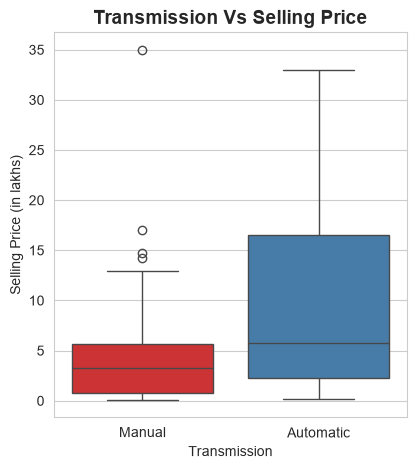

In [14]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.boxplot(x="Transmission",y="Selling_Price",data=car_dataset,palette="Set1")
plt.title("Transmission Vs Selling Price",fontsize=14,fontweight="bold")
plt.ylabel("Selling Price (in lakhs)")
plt.xlabel("Transmission")
plt.show()

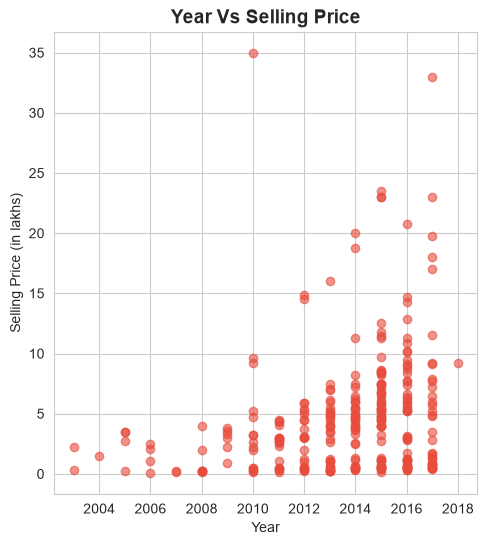

In [15]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.scatter(car_dataset["Year"],car_dataset["Selling_Price"], alpha=0.6,c="#e74c3c")
plt.title("Year Vs Selling Price",fontsize=14,fontweight="bold")
plt.ylabel("Selling Price (in lakhs)")
plt.xlabel("Year")
plt.show()

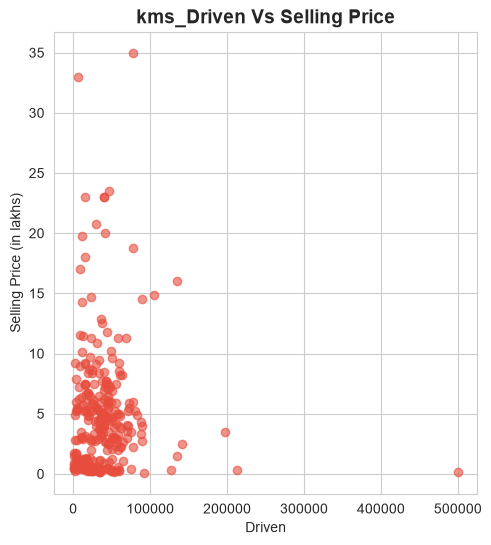

In [16]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.scatter(car_dataset["Kms_Driven"],car_dataset["Selling_Price"], alpha=0.6,c="#e74c3c")
plt.title("kms_Driven Vs Selling Price",fontsize=14,fontweight="bold")
plt.ylabel("Selling Price (in lakhs)")
plt.xlabel("Driven")
plt.show()

In [17]:
car=car_dataset.copy()

In [18]:
le = LabelEncoder()
car["Fuel_Type"] = le.fit_transform(car["Fuel_Type"])#petrol->2,diesel->1,cng->0
car["Seller_Type"] = le.fit_transform(car["Seller_Type"])#dealer-0,individual->1
car["Transmission"] = le.fit_transform(car["Transmission"])#automatic and manual->0,1

In [19]:
car.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,2,0,1,0
1,sx4,2013,4.75,9.54,43000,1,0,1,0
2,ciaz,2017,7.25,9.85,6900,2,0,1,0
3,wagon r,2011,2.85,4.15,5200,2,0,1,0
4,swift,2014,4.60,6.87,42450,1,0,1,0


In [20]:
#MODEL SELECTION
x=car.drop(["Car_Name","Selling_Price"],axis=1)
y=car["Selling_Price"]

In [21]:
x.head()

,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,5.59,27000,2,0,1,0
1,2013,9.54,43000,1,0,1,0
2,2017,9.85,6900,2,0,1,0
3,2011,4.15,5200,2,0,1,0
4,2014,6.87,42450,1,0,1,0


In [22]:
y.head()

0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64

In [23]:
#TRAIN TEST SPLIT
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [24]:
print(f"Training Sample:{x_train.shape[0]}(80%)")


Training Sample:240(80%)


In [25]:
print(f"Testing Sample:{x_test.shape[0]}(20%)")

Testing Sample:61(20%)


In [26]:
#MODEL 1->LINEAR REGRESSION
LR=LinearRegression()
LR.fit(x_train,y_train)

train_pred_lr=LR.predict(x_train)


In [27]:
train_r2_lr=metrics.r2_score(y_train,train_pred_lr)


In [28]:
train_mae_lr=metrics.mean_absolute_error(y_train,train_pred_lr)
train_rmse_lr=np.sqrt(metrics.mean_squared_error(y_train,train_pred_lr))


In [29]:
print("R2 Score",train_r2_lr)
print("MAE Score",train_mae_lr)
print("RMSE",train_rmse_lr)

R2 Score 0.8838169193709796
MAE Score 1.199852024214238
RMSE 1.7909012678408893


In [30]:
test_pred_lr = LR.predict(x_test)

test_r2_lr = metrics.r2_score(y_test, test_pred_lr)

test_mae_lr = metrics.mean_absolute_error(y_test, test_pred_lr)
test_rmse_lr = np.sqrt(metrics.mean_squared_error(y_test, test_pred_lr))

print("R2 Score",test_r2_lr)
print("MAE Score",test_mae_lr)
print("RMSE",test_rmse_lr)


R2 Score 0.8401532365378493
MAE Score 1.2671998472909285
RMSE 1.7134244742419136


Text(0.5, 1.0, 'Linear Regression')

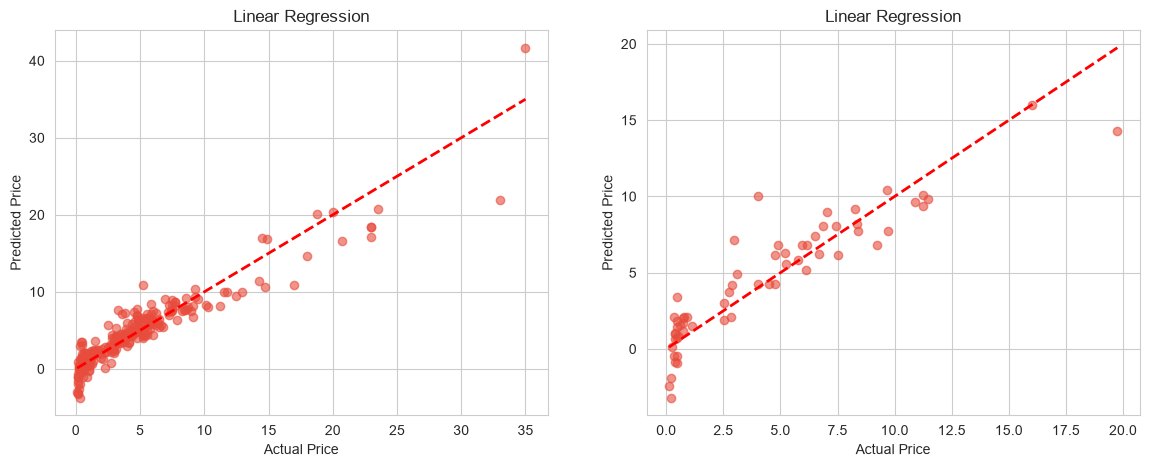

In [31]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].scatter(y_train,train_pred_lr,alpha=0.6,c="#e74c3c")
axes[0].plot([y_train.min(),y_train.max()],[y_train.min(),y_train.max()],"r--",lw=2)
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].set_title("Linear Regression")

axes[1].scatter(y_test,test_pred_lr,alpha=0.6,c="#e74c3c")
axes[1].plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],"r--",lw=2)
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")
axes[1].set_title("Linear Regression")



In [32]:
# METHOD-2 LASSO REGRESSION
lasso_reg=Lasso(alpha=0.1)
lasso_reg.fit(x_train,y_train)

train_pred_ls = lasso_reg.predict(x_train)

train_r2_ls = metrics.r2_score(y_train, train_pred_ls)

train_mae_ls = metrics.mean_absolute_error(y_train, train_pred_ls)
train_rmse_ls = np.sqrt(metrics.mean_squared_error(y_train, train_pred_ls))

print("R2 Score",train_r2_ls)
print("MAE Score",train_mae_ls)
print("RMSE",train_rmse_ls)


R2 Score 0.8736452471129412
MAE Score 1.1920859027644946
RMSE 1.8676521468922187


In [33]:
test_pred_ls = lasso_reg.predict(x_test)

test_r2_ls = metrics.r2_score(y_test, test_pred_ls)

test_mae_ls = metrics.mean_absolute_error(y_test, test_pred_ls)
test_rmse_ls = np.sqrt(metrics.mean_squared_error(y_test, test_pred_ls))

print("R2 Score",test_r2_ls)
print("MAE Score",test_mae_ls)
print("RMSE",test_rmse_ls)

R2 Score 0.8578767759929418
MAE Score 1.2038465262647091
RMSE 1.6156436117415036


Text(0.5, 1.0, 'Lasso Regression')

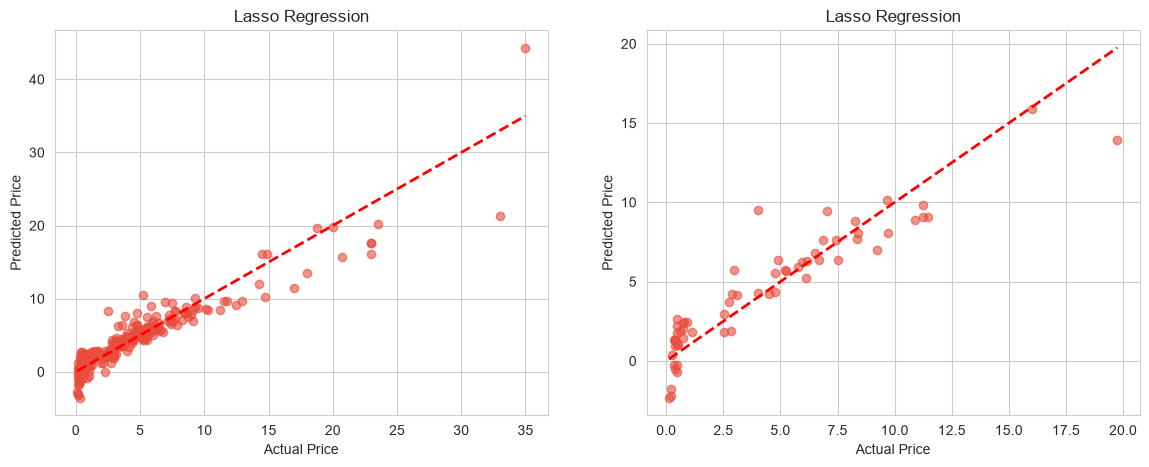

In [34]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].scatter(y_train,train_pred_ls,alpha=0.6,c="#e74c3c")
axes[0].plot([y_train.min(),y_train.max()],[y_train.min(),y_train.max()],"r--",lw=2)
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].set_title("Lasso Regression")

axes[1].scatter(y_test,test_pred_ls,alpha=0.6,c="#e74c3c")
axes[1].plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],"r--",lw=2)
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")
axes[1].set_title("Lasso Regression")

In [35]:
# METHOD-3 RANDOM FOREST
rf= RandomForestRegressor(n_estimators=100,random_state=2)
rf.fit(x_train,y_train)

train_pred_rf = rf.predict(x_train)

train_r2_rf = metrics.r2_score(y_train, train_pred_rf)

train_mae_rf = metrics.mean_absolute_error(y_train, train_pred_rf)
train_rmse_rf = np.sqrt(metrics.mean_squared_error(y_train, train_pred_rf))

print("R2 Score",train_r2_rf)
print("MAE Score",train_mae_rf)
print("RMSE",train_rmse_rf)


R2 Score 0.9874926805940208
MAE Score 0.24023333333333305
RMSE 0.5876007215788623


In [36]:
test_pred_rf = rf.predict(x_test)

test_r2_rf = metrics.r2_score(y_test, test_pred_rf)

test_mae_rf = metrics.mean_absolute_error(y_test, test_pred_rf)
test_rmse_rf = np.sqrt(metrics.mean_squared_error(y_test, test_pred_rf))

print("R2 Score",test_r2_rf)
print("MAE Score",test_mae_rf)
print("RMSE",test_rmse_rf)

R2 Score 0.962228902700314
MAE Score 0.4679885245901641
RMSE 0.8328999639812699


In [37]:
feature_imp = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)
print(feature_imp)

         Feature  Importance
1  Present_Price    0.885322
0           Year    0.082514
2     Kms_Driven    0.016835
5   Transmission    0.005154
4    Seller_Type    0.004660
3      Fuel_Type    0.004621
6          Owner    0.000894


Text(0.5, 1.0, 'Random Forest')

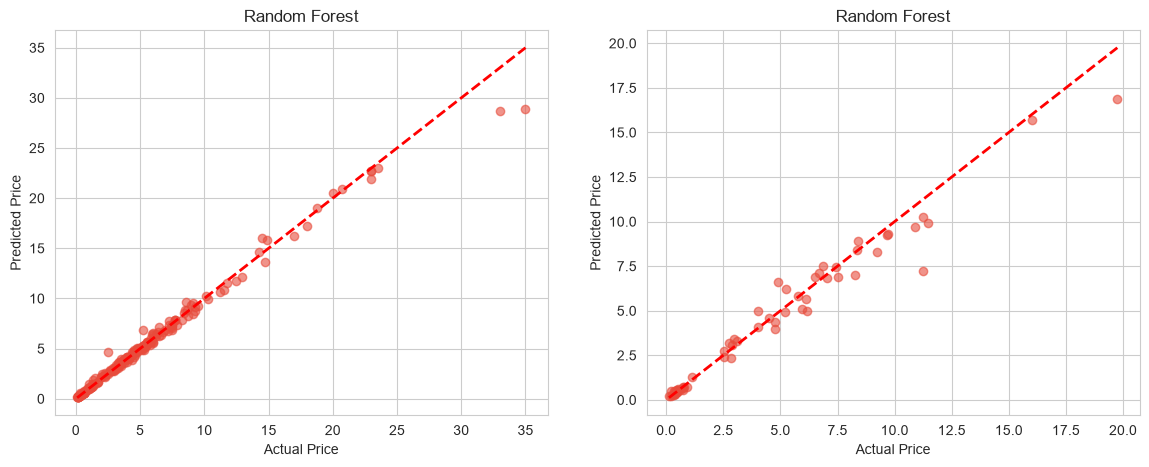

In [38]:
ig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].scatter(y_train,train_pred_rf,alpha=0.6,c="#e74c3c")
axes[0].plot([y_train.min(),y_train.max()],[y_train.min(),y_train.max()],"r--",lw=2)
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].set_title("Random Forest")

axes[1].scatter(y_test,test_pred_rf,alpha=0.6,c="#e74c3c")
axes[1].plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],"r--",lw=2)
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")
axes[1].set_title("Random Forest")

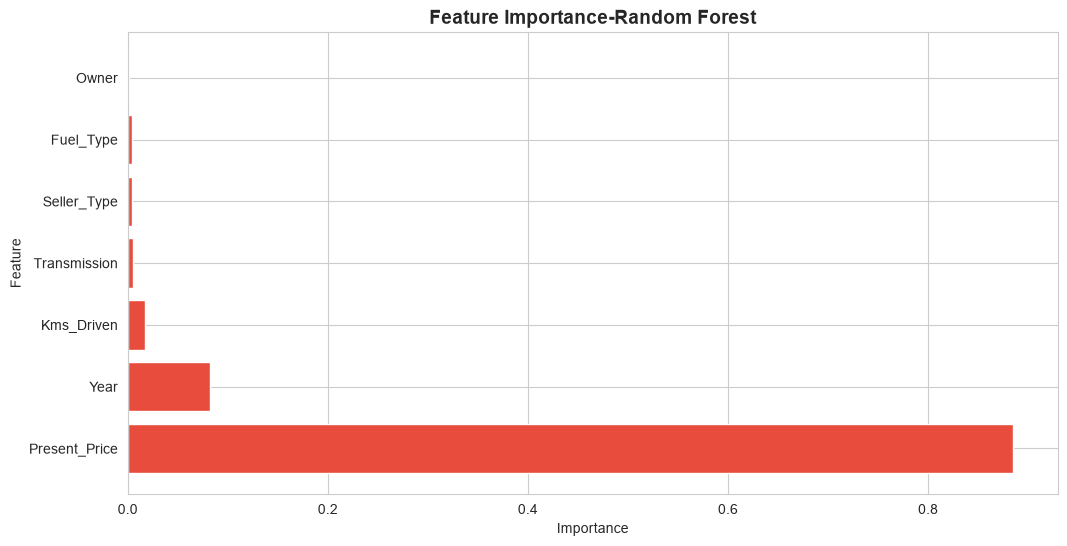

In [39]:
plt.figure(figsize=(12, 6))
plt.barh(feature_imp["Feature"], feature_imp["Importance"], color="#e74c3c")
plt.title("Feature Importance-Random Forest", fontsize=14, fontweight="bold")
plt.ylabel("Feature")
plt.xlabel("Importance")
plt.show()

In [40]:
#MODEL COMPARISION
print("Linear Regression",test_r2_lr)
print("Lasso Regression",test_r2_ls)
print("Randon Forest",test_r2_rf)


Linear Regression 0.8401532365378493
Lasso Regression 0.8578767759929418
Randon Forest 0.962228902700314


In [41]:
#save best model
joblib.dump(rf,"Car_Prediction_Model.pkl")

['Car_Prediction_Model.pkl']

In [42]:
#Testing Model
input_data = pd.DataFrame({
    'Year': [2015],
    'Present_Price': [7.0],
    'Kms_Driven': [50000],
    'Fuel_Type':[0],
    'Seller_Type':[1],
    'Transmission': [0],
    'Owner': [1]
})

prediction = rf.predict(input_data)[0]
print(prediction)

4.638499999999999
